# **UNDERSTANDING CONTENT ENGAGEMENT AND ITS IMPACT ON AIRLINE TICKET PURCHASES**

In [ ]:
#Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#To supress warnings
import warnings
warnings.filterwarnings('ignore')


In [ ]:
#mounting google drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/My Drive/AeroReach Insights.csv'

df = pd.read_csv(file_path)

In [ ]:
#Checking number of columns and rows
df.shape

(11760, 17)

In [ ]:
df.head(10)

,UserID,Taken_product,Yearly_avg_view_on_travel_page,preferred_device,total_likes_on_outstation_checkin_given,yearly_avg_Outstation_checkins,member_in_family,preferred_location_type,Yearly_avg_comment_on_travel_page,total_likes_on_outofstation_checkin_received,week_since_last_outstation_checkin,following_company_page,montly_avg_comment_on_company_page,working_flag,travelling_network_rating,Adult_flag,Daily_Avg_mins_spend_on_traveling_page
0,1000001,Yes,307.0,iOS and Android,38570.0,1,2,Financial,94.0,5993,8,Yes,11,No,1,0,8
1,1000002,No,367.0,iOS,9765.0,1,1,Financial,61.0,5130,1,No,23,Yes,4,1,10
2,1000003,Yes,277.0,iOS and Android,48055.0,1,2,Other,92.0,2090,6,Yes,15,No,2,0,7
3,1000004,No,247.0,iOS,48720.0,1,4,Financial,56.0,2909,1,Yes,11,No,3,0,8
4,1000005,No,202.0,iOS and Android,20685.0,1,1,Medical,40.0,3468,9,No,12,No,4,1,6
5,1000006,No,240.0,iOS,35175.0,1,2,Financial,79.0,3068,0,No,13,No,3,0,8
6,1000007,No,NaN,iOS and Android,46340.0,1,Three,Medical,81.0,2670,4,Yes,20,Yes,1,3,12
7,1000008,No,225.0,iOS and Android,NaN,24,1,Financial,67.0,2693,1,No,22,Yes,2,1,1
8,1000009,No,285.0,iOS,7560.0,23,3,Financial,44.0,9526,0,No,21,Yes,2,0,10
9,1000010,No,270.0,iOS and Android,45465.0,27,3,NaN,94.0,5237,6,No,13,No,2,2,17


In [ ]:
#checking information about columns, its data type and any missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11760 entries, 0 to 11759
Data columns (total 17 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   UserID                                        11760 non-null  int64  
 1   Taken_product                                 11760 non-null  object 
 2   Yearly_avg_view_on_travel_page                11179 non-null  float64
 3   preferred_device                              11707 non-null  object 
 4   total_likes_on_outstation_checkin_given       11379 non-null  float64
 5   yearly_avg_Outstation_checkins                11685 non-null  object 
 6   member_in_family                              11760 non-null  object 
 7   preferred_location_type                       11729 non-null  object 
 8   Yearly_avg_comment_on_travel_page             11554 non-null  float64
 9   total_likes_on_outofstation_checkin_received  11760 non-null 

**INSIGHT**



*   A few columns have null values, which we will suitably treat further.
*   'yearly_avg_Outstation_checkins' has object data type, which is suspicious.
*   'member_in_family' has object data type, which is suspicious.

We will further explore to see and correct these mistake in our data.





**INFERENCE**

*   Data set might contain invalid values or a single column might have mixed data type.




In [ ]:
#checking data quality of member in family column
df['member_in_family'].value_counts()

,count
member_in_family,
3,4561
4,3184
2,2256
1,1349
5,384
Three,15
10,11




*   We can see an invalid dtype 'Three'.


*   This will be replaced with '3'.





In [ ]:
#writing code to replace the incorrect data type
df['member_in_family'] = df['member_in_family'].replace({ 'Three':'3'})

In [ ]:
df['member_in_family'].value_counts()

,count
member_in_family,
3,4576
4,3184
2,2256
1,1349
5,384
10,11




*   Incorrect data has been corrected.
*   Although the value '10' might seem as an outlier, it makes logical sense in the context of the data. Therefore, we will retain it without any modification.



In [ ]:
#converting from object to int dtype
df['member_in_family'] = df['member_in_family'].astype(int)
df['member_in_family'].dtype

dtype('int64')

In [ ]:
#yearly avg out checkins is showing as object. need to investigate why as it is supposed to be a int type
df['yearly_avg_Outstation_checkins'].unique()


array(['1', '24', '23', '27', '16', '15', '26', '19', '21', '11', '10',
       '25', '12', '18', '29', nan, '22', '14', '20', '28', '17', '13',
       '*', '5', '8', '2', '3', '9', '7', '6', '4'], dtype=object)


*   we can see there are 'nan' values and an invalid value '*'.



In [ ]:
#checking how many such values are present
(df['yearly_avg_Outstation_checkins'] == '*').sum()


np.int64(1)


*   There is only 1 cell which contains the 'invalid value'.




In [ ]:
# replacing '*' with nan
df['yearly_avg_Outstation_checkins'] = df['yearly_avg_Outstation_checkins'].replace('*', np.nan)



In [ ]:
#converting to numeric
df['yearly_avg_Outstation_checkins'] = pd.to_numeric(df['yearly_avg_Outstation_checkins'])


In [ ]:
df['yearly_avg_Outstation_checkins'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 11760 entries, 0 to 11759
Series name: yearly_avg_Outstation_checkins
Non-Null Count  Dtype  
--------------  -----  
11684 non-null  float64
dtypes: float64(1)
memory usage: 92.0 KB





*   '*' value has been converted to a null value which will be imputed further suitably.
*   the data type has been chnaged to a numeric ( float).




In [ ]:
#Checking Adult flag column data quality
df['Adult_flag'].value_counts()


,count
Adult_flag,
0,5048
1,4768
2,1264
3,680


**INSIGHT**

*   This column should ideally be a binary (Yes/No).
*   Since this is raw data we will assume a certain category for the values, assuming it is already label-encoded.

**ASSUMPTION**

15-25 : 0

26-35 : 1   

36-45 : 2

46+   : 3



*   Hence there is no need of any treatement to the Adult_flag column





In [ ]:
#Checking for data quality of this column
df['UserID'].nunique()

11760


*   Since shape of our data is 11760, It is confirmed that their are 11760 unique users.


In [ ]:
df.describe()

,UserID,Yearly_avg_view_on_travel_page,total_likes_on_outstation_checkin_given,yearly_avg_Outstation_checkins,member_in_family,Yearly_avg_comment_on_travel_page,total_likes_on_outofstation_checkin_received,week_since_last_outstation_checkin,montly_avg_comment_on_company_page,travelling_network_rating,Adult_flag,Daily_Avg_mins_spend_on_traveling_page
count,1.176000e+04,11179.000000,11379.000000,11684.000000,11760.000000,11554.000000,11760.000000,11760.000000,11760.000000,11760.000000,11760.000000,11760.000000
mean,1.005880e+06,280.830844,28170.481765,8.223554,2.921344,74.790029,6531.699065,3.203571,28.661565,2.712245,0.793878,13.817432
std,3.394964e+03,68.182958,14385.032134,8.672398,1.044883,24.026650,4706.613785,2.616365,48.660504,1.080887,0.851823,9.070657
min,1.000001e+06,35.000000,3570.000000,1.000000,1.000000,3.000000,1009.000000,0.000000,11.000000,1.000000,0.000000,0.000000
25%,1.002941e+06,232.000000,16380.000000,1.000000,2.000000,57.000000,2940.750000,1.000000,17.000000,2.000000,0.000000,8.000000
50%,1.005880e+06,271.000000,28076.000000,4.000000,3.000000,75.000000,4948.000000,3.000000,22.000000,3.000000,1.000000,12.000000
75%,1.008820e+06,324.000000,40525.000000,14.000000,4.000000,92.000000,8393.250000,5.000000,27.000000,4.000000,1.000000,18.000000
max,1.011760e+06,464.000000,252430.000000,29.000000,10.000000,815.000000,20065.000000,11.000000,500.000000,4.000000,3.000000,270.000000


In [ ]:
#defining a function to give us the percentage of null values
def null_values(df):
  return round((df.isnull().sum() *100/len(df)). sort_values(ascending = False),2)
null_values(df)




,0
Yearly_avg_view_on_travel_page,4.94
total_likes_on_outstation_checkin_given,3.24
Yearly_avg_comment_on_travel_page,1.75
following_company_page,0.88
yearly_avg_Outstation_checkins,0.65
preferred_device,0.45
preferred_location_type,0.26
UserID,0.00
Taken_product,0.00
member_in_family,0.00


**DECISION**


*   Since the columns have less than 15% missing value , we will impute those missing values suitably
*   This will ensure good data quality and better insights



In [ ]:
#plotting distribution of columns to check for data skewness

cols_to_plot = ['Yearly_avg_view_on_travel_page',
                'total_likes_on_outstation_checkin_given',
                'Yearly_avg_comment_on_travel_page',
                'yearly_avg_Outstation_checkins',
                'montly_avg_comment_on_company_page',
                'Daily_Avg_mins_spend_on_traveling_page',
                'total_likes_on_outstation_checkin_given',
                'week_since_last_outstation_checkin',
                'total_likes_on_outofstation_checkin_received','Adult_flag','member_in_family'
                ]

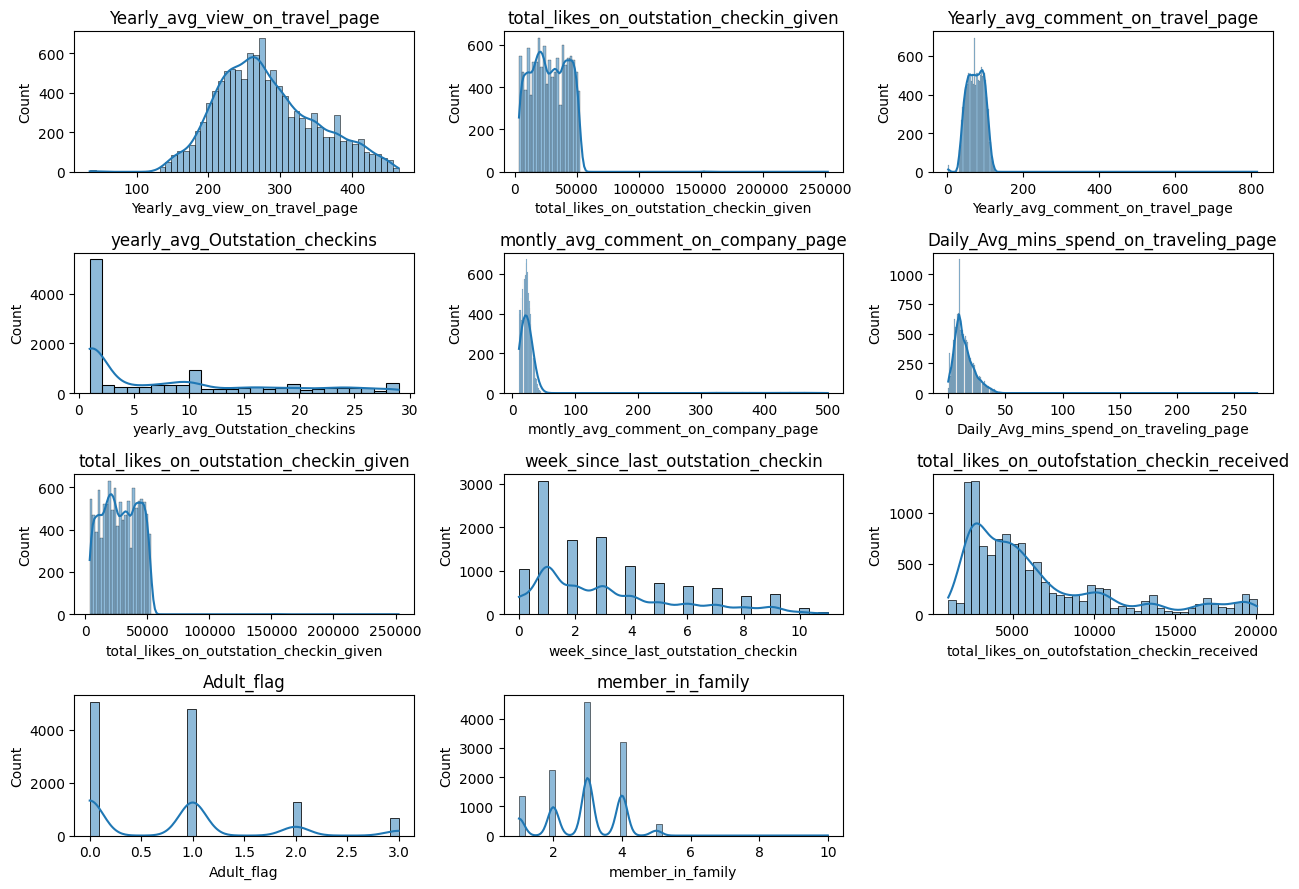

In [ ]:
plt.figure(figsize=(13,9))
for i, col in enumerate(cols_to_plot,1):
  plt.subplot(4,3,i)
  sns.histplot(df[col], kde=True)
  plt.title(f'{col}')
  plt.xlabel(col)

plt.tight_layout()
plt.show()

**INSIGHT**


*   'Yearly_avg_view_on_travel_page' almost has a normal distribution.
*   'total_likes_on_outstation_checkin_given has a positive skew.
*   'Yearly_avg_comment_on_travel_page' almost has a normal distribution.
*   'yearly_avg_Outstation_checkins has a positive skew.

*   Daily_Avg_mins_spend_on_traveling_page has a positive skew
*   total_likes_on_outofstation_checkin_received has a positive skew







In [ ]:
#imputing missing values
df['Yearly_avg_view_on_travel_page'] = df['Yearly_avg_view_on_travel_page'].fillna(df['Yearly_avg_view_on_travel_page'].mean())
df['Yearly_avg_comment_on_travel_page'] = df['Yearly_avg_comment_on_travel_page'].fillna(df['Yearly_avg_comment_on_travel_page'].mean())
df['total_likes_on_outstation_checkin_given'] = df['total_likes_on_outstation_checkin_given'].fillna(df['total_likes_on_outstation_checkin_given'].median())
df['yearly_avg_Outstation_checkins'] = df['yearly_avg_Outstation_checkins'].fillna(df['yearly_avg_Outstation_checkins'].median())



Null values have been filled with appropriate values(mean/mode) as deemed fit

*   'Yearly_avg_view_on_travel_page' & 'Yearly_avg_comment_on_travel_page' are imputed with mean as they almost has a normal distribution.
*   'total_likes_on_outstation_checkin_given' & 'yearly_avg_Outstation_checkins' are imputated with median as they have positive skew.



In [ ]:
df['following_company_page'].value_counts(dropna=False)


,count
following_company_page,
No,8355
Yes,3285
NaN,103
1,12
0,5




*   The column has mixed data types, which we will now convert for consistency.

*   It also contains missing values, which will be treated during the process.












In [ ]:
#maping the 1 & 0 to yes or no
df['following_company_page'] = df['following_company_page'].replace({
    '1': 'Yes',
    '0': 'No'
})


In [ ]:
#Filling out missing values with mode since it is a true or false column

df['following_company_page'] = df['following_company_page'].fillna(df['following_company_page'].mode()[0])



In [ ]:
#checking for data cleaning if done
df['following_company_page'].value_counts(dropna=False)


,count
following_company_page,
No,8463
Yes,3297


In [ ]:
#checking contents os preferred device column
df['preferred_device'].value_counts(dropna=False)


,count
preferred_device,
Tab,4172
iOS and Android,4134
Laptop,1108
iOS,1095
Mobile,600
Android,315
Android OS,145
ANDROID,134
NaN,53




*   We can see that , instead of mentioning the device, the OS has been mentioned.
*   We will correct this by replacing the incorrect values.




In [ ]:
# corrected incorrect values
df['preferred_device'] = df['preferred_device'].replace({
    'ANDROID': 'Mobile',
    'Android OS': 'Mobile',
    'iOS' : 'Mobile',
    'iOS and Android': 'Mobile',
    'Android' : 'Mobile',
    'Others': 'Other'
})

In [ ]:
# Filling all null values with the mode of the column since it is a categorical column
mode_value_device= df['preferred_device'].mode()[0]
df['preferred_device'].fillna(mode_value_device, inplace=True)

In [ ]:
df['preferred_device'].value_counts(dropna=False)


,count
preferred_device,
Mobile,6476
Tab,4172
Laptop,1108
Other,4




*   Since only 4 count of values are present in 'Other' and also most commonly used device are Laptop, Mobile or Tab.
*   We will replace 'Other' with Mobile which is the mode.



In [ ]:
df['preferred_device'] = df['preferred_device'].replace({
    'Other' :'Mobile'
})

In [ ]:
df['preferred_device'].value_counts(dropna=False)

,count
preferred_device,
Mobile,6480
Tab,4172
Laptop,1108



*   After data correction and imputing, we have taken care of missing values and incorrect data format.




In [ ]:
df['preferred_location_type'].value_counts(dropna=False)


,count
preferred_location_type,
Beach,2424
Financial,2409
Historical site,1856
Medical,1845
Other,643
Big Cities,636
Social media,633
Trekking,528
Entertainment,516




*   This column has incorrect category labels, which we will further clean and impute suitably



In [ ]:
# correcting incorrect categories
df['preferred_location_type'] = df['preferred_location_type'].replace(
    {
    'Tour  Travel': 'Other',
    'Tour and Travel': 'Other',
    'Social media' : 'Unknown',
    'Game' : 'Other',
    'OTT' : 'Other',
    'Movie' : 'Other'
}
)

In [ ]:
#Filling missing values with a new category 'Unkown'
df['preferred_location_type'] = df['preferred_location_type'].fillna('Unknown')

In [ ]:
df['preferred_location_type'].value_counts(dropna=False)


,count
preferred_location_type,
Beach,2424
Financial,2409
Historical site,1856
Medical,1845
Other,774
Unknown,664
Big Cities,636
Trekking,528
Entertainment,516



*   Missing values filled with a new category 'Unkown'.
*   Any value which seemed incorrect, merged with the 'Other' category.
*   "Financial" category is retained assuming it means travel for business purpose.





In [ ]:
null_values(df)

,0
UserID,0.0
Taken_product,0.0
Yearly_avg_view_on_travel_page,0.0
preferred_device,0.0
total_likes_on_outstation_checkin_given,0.0
yearly_avg_Outstation_checkins,0.0
member_in_family,0.0
preferred_location_type,0.0
Yearly_avg_comment_on_travel_page,0.0
total_likes_on_outofstation_checkin_received,0.0



*   All Null values have been suitably treated and taken care of.




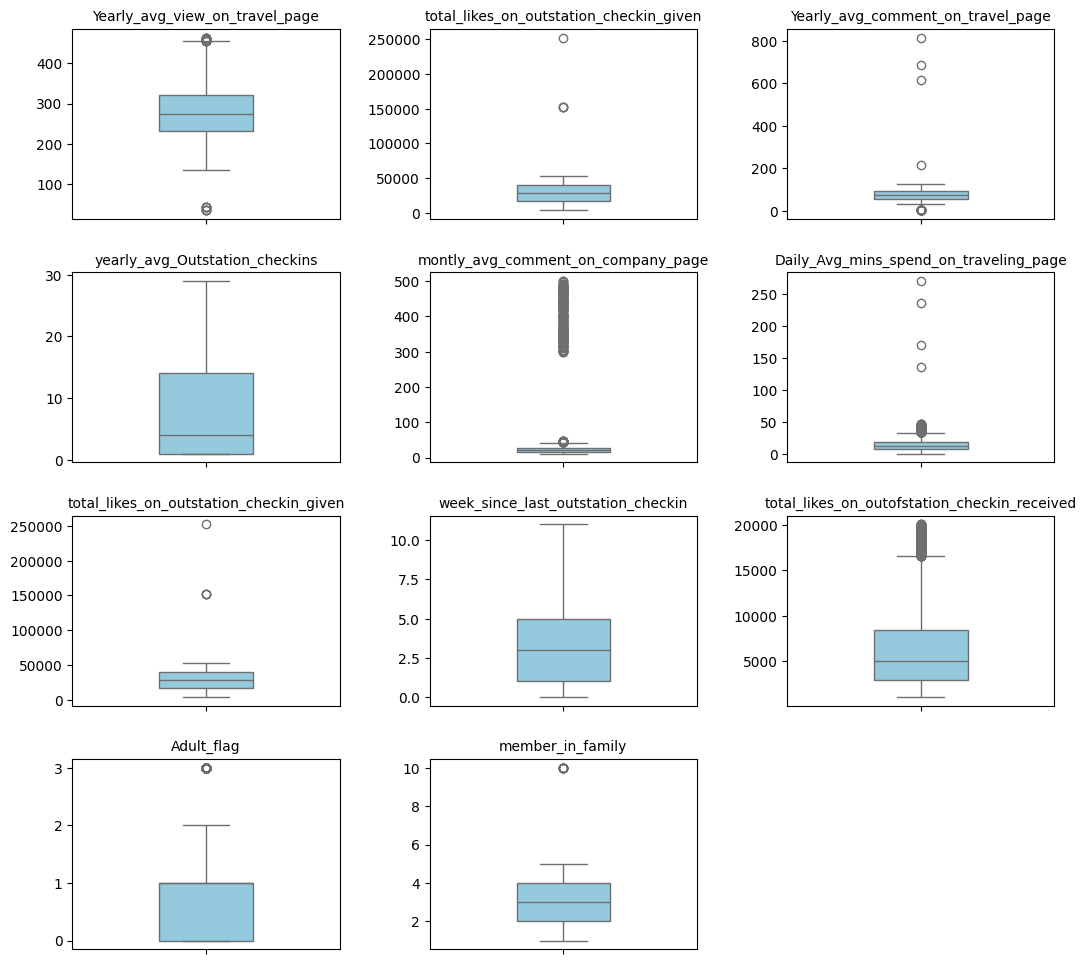

In [ ]:
# Now we will check for outliers in all our columns

plt.figure(figsize=(11, 10))

# Create each subplot
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col], width=0.35, color='skyblue')
    plt.title(col, fontsize=10)
    plt.ylabel('')
    plt.xlabel('')

plt.tight_layout(pad=2)
plt.show()



*   As seen in above box plots, there are extreme outliers in some columns, which will significantly affect our ML model, hence we will now treat the outliers with mean/median as deemed fit.




In [ ]:
  #Writing a function to have a look at the outlier values and their counts

  def IQR_details(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    Min_value = Q1 - (1.5*IQR)
    Max_value = Q3 + (1.5*IQR)
    print(f"Min value for '{col}' is {Min_value}")
    value_counts_min = df[df[col] < Min_value][col].value_counts()
    print(value_counts_min)
    print("\n")
    print(f"Max value for '{col}' is {Max_value}")
    value_counts_max = df[df[col] > Max_value][col].value_counts()
    print(value_counts_max)

In [ ]:
IQR_details('Yearly_avg_view_on_travel_page')

Min value for 'Yearly_avg_view_on_travel_page' is 99.5
Yearly_avg_view_on_travel_page
42.0    5
35.0    4
Name: count, dtype: int64


Max value for 'Yearly_avg_view_on_travel_page' is 455.5
Yearly_avg_view_on_travel_page
456.0    5
457.0    3
460.0    3
461.0    2
459.0    2
462.0    2
458.0    1
464.0    1
463.0    1
Name: count, dtype: int64


we can see what are the values posing as outliers and count of each value.

In [ ]:
#defining a function which we can call to correct the outlier values in each of our columns
def Outlier_correction(col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  Min_value = Q1 - (1.5*IQR)
  Max_value = Q3 + (1.5*IQR)
  median_value = df[col].median()
  print(f"Median of this column is:{median_value}")
  print(f"Min value for '{col}' is {Min_value}")
  print(f"Max value for '{col}' is {Max_value}")
  df.loc[df[col] < Min_value, col] = median_value
  df.loc[df[col] > Max_value, col] = median_value

  #All outliers will be replaced with the median of the column by calling this function

In [ ]:
#Imputing outliers with the mean value by calling our function
Outlier_correction('Yearly_avg_view_on_travel_page')

Median of this column is:275.0
Min value for 'Yearly_avg_view_on_travel_page' is 101.0
Max value for 'Yearly_avg_view_on_travel_page' is 453.0


In [ ]:
IQR_details('Yearly_avg_view_on_travel_page')

Min value for 'Yearly_avg_view_on_travel_page' is 101.0
Series([], Name: count, dtype: int64)


Max value for 'Yearly_avg_view_on_travel_page' is 453.0
Series([], Name: count, dtype: int64)


Outliers for the column 'Yearly_avg_view_on_travel_page ' have been fixed.

In [ ]:
IQR_details('total_likes_on_outstation_checkin_given')


Min value for 'total_likes_on_outstation_checkin_given' is -18429.75
Series([], Name: count, dtype: int64)


Max value for 'total_likes_on_outstation_checkin_given' is 75242.25
total_likes_on_outstation_checkin_given
152465.0    2
252430.0    1
152430.0    1
Name: count, dtype: int64


In [ ]:
median_val_likes_on_oustation_checkins = df['total_likes_on_outstation_checkin_given'].median()
print(f"Median of this column is:{median_val_likes_on_oustation_checkins}")
df.loc[df['total_likes_on_outstation_checkin_given'] > 75242.25, 'total_likes_on_outstation_checkin_given'] = median_val_likes_on_oustation_checkins


Median of this column is:28076.0


In [ ]:
IQR_details('total_likes_on_outstation_checkin_given')


Min value for 'total_likes_on_outstation_checkin_given' is -18422.25
Series([], Name: count, dtype: int64)


Max value for 'total_likes_on_outstation_checkin_given' is 75229.75
Series([], Name: count, dtype: int64)


this confirms no value is present below our min value and above our max value, hence outliers are removed.

In [ ]:
IQR_details('Yearly_avg_comment_on_travel_page')

Min value for 'Yearly_avg_comment_on_travel_page' is 4.5
Yearly_avg_comment_on_travel_page
3.0    36
Name: count, dtype: int64


Max value for 'Yearly_avg_comment_on_travel_page' is 144.5
Yearly_avg_comment_on_travel_page
615.0    1
215.0    1
815.0    1
685.0    1
Name: count, dtype: int64


We will treat the outliers in this data by replacing them with the median value.

In [ ]:
Outlier_correction('Yearly_avg_comment_on_travel_page')

Median of this column is:74.79002942703825
Min value for 'Yearly_avg_comment_on_travel_page' is 4.5
Max value for 'Yearly_avg_comment_on_travel_page' is 144.5


In [ ]:
IQR_details('Yearly_avg_comment_on_travel_page')

Min value for 'Yearly_avg_comment_on_travel_page' is 7.0
Series([], Name: count, dtype: int64)


Max value for 'Yearly_avg_comment_on_travel_page' is 143.0
Series([], Name: count, dtype: int64)


No Outliers present now

In [ ]:
IQR_details('montly_avg_comment_on_company_page')

Min value for 'montly_avg_comment_on_company_page' is 2.0
Series([], Name: count, dtype: int64)


Max value for 'montly_avg_comment_on_company_page' is 42.0
montly_avg_comment_on_company_page
44     17
43     16
45     11
46      5
376     3
       ..
449     1
414     1
337     1
47      1
48      1
Name: count, Length: 128, dtype: int64


In [ ]:
Outlier_correction('montly_avg_comment_on_company_page')

Median of this column is:22.0
Min value for 'montly_avg_comment_on_company_page' is 2.0
Max value for 'montly_avg_comment_on_company_page' is 42.0


In [ ]:
IQR_details('montly_avg_comment_on_company_page')

Min value for 'montly_avg_comment_on_company_page' is 2.0
Series([], Name: count, dtype: int64)


Max value for 'montly_avg_comment_on_company_page' is 42.0
Series([], Name: count, dtype: int64)


In [ ]:
IQR_details('Daily_Avg_mins_spend_on_traveling_page')

Min value for 'Daily_Avg_mins_spend_on_traveling_page' is -7.0
Series([], Name: count, dtype: int64)


Max value for 'Daily_Avg_mins_spend_on_traveling_page' is 33.0
Daily_Avg_mins_spend_on_traveling_page
34     62
36     56
35     48
37     46
40     32
38     30
39     26
41     20
44      8
42      6
45      4
43      4
46      3
135     1
170     1
235     1
270     1
47      1
Name: count, dtype: int64



*   Even though mathematically all values above 33 are outliers, but sensibly it is very much possible for a person to spend more than 33 mins on a traveling page.


*   Hence we will replace all values greater than 60 with the median of the column.



In [ ]:
# Let's first calculate the median of the column
median_val = df['Daily_Avg_mins_spend_on_traveling_page'].median()
print(f"The median value for this column is: {median_val}")
# Now replace all values greater than 60 with the median
df.loc[df['Daily_Avg_mins_spend_on_traveling_page'] > 60, 'Daily_Avg_mins_spend_on_traveling_page'] = median_val

The median value for this column is: 12.0


In [ ]:
IQR_details('Daily_Avg_mins_spend_on_traveling_page')

Min value for 'Daily_Avg_mins_spend_on_traveling_page' is -7.0
Series([], Name: count, dtype: int64)


Max value for 'Daily_Avg_mins_spend_on_traveling_page' is 33.0
Daily_Avg_mins_spend_on_traveling_page
34    62
36    56
35    48
37    46
40    32
38    30
39    26
41    20
44     8
42     6
43     4
45     4
46     3
47     1
Name: count, dtype: int64


All values Above 60 have been replaced with the median value

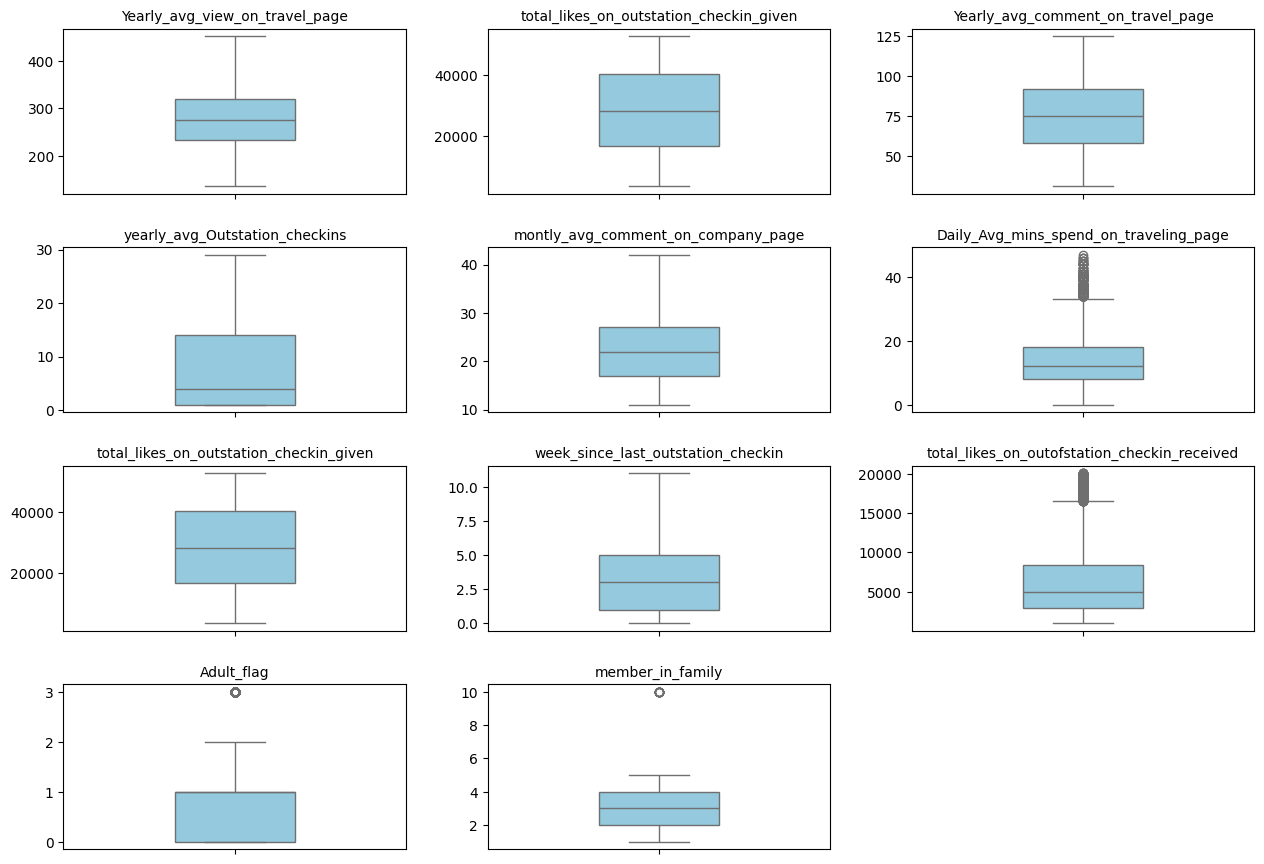

In [ ]:
plt.figure(figsize=(13, 9))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col], width=0.35, color='skyblue')
    plt.title(col, fontsize=10)
    plt.ylabel('')
    plt.xlabel('')

plt.tight_layout(pad=2)
plt.show()



*   As compared to previous subplot, now we can see all outliers are treated suitably.

*   Four columns have outliers mathematically, but we have decided no to treat them as logically they are not outliers and there is a real world possibility for them to exist.



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11760 entries, 0 to 11759
Data columns (total 17 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   UserID                                        11760 non-null  int64  
 1   Taken_product                                 11760 non-null  object 
 2   Yearly_avg_view_on_travel_page                11760 non-null  float64
 3   preferred_device                              11760 non-null  object 
 4   total_likes_on_outstation_checkin_given       11760 non-null  float64
 5   yearly_avg_Outstation_checkins                11760 non-null  float64
 6   member_in_family                              11760 non-null  int64  
 7   preferred_location_type                       11760 non-null  object 
 8   Yearly_avg_comment_on_travel_page             11760 non-null  float64
 9   total_likes_on_outofstation_checkin_received  11760 non-null 



*   There are no null values now.
*   Dtype of all columns is also suitably correct.


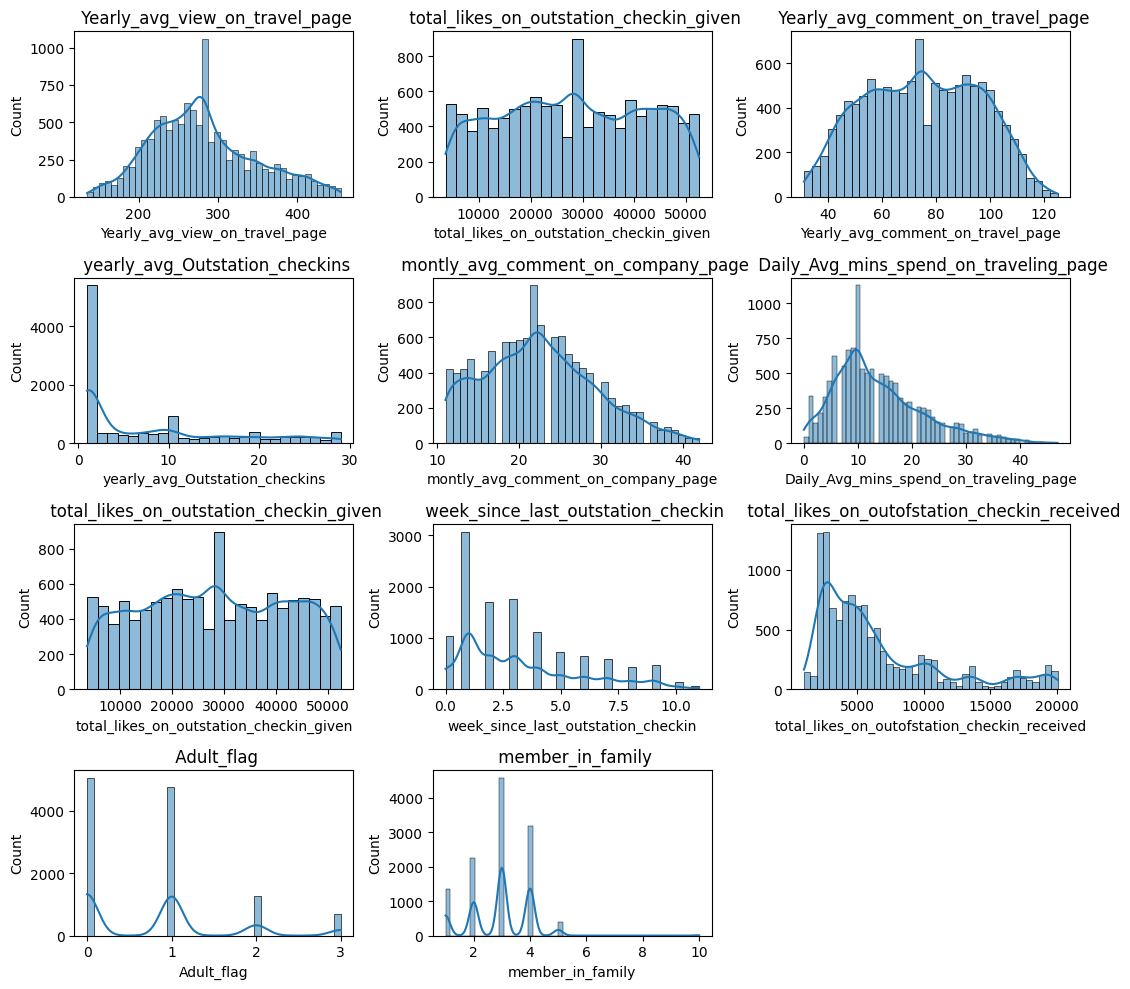

In [ ]:
plt.figure(figsize=(11,10))
for i, col in enumerate(cols_to_plot,1):
  plt.subplot(4,3,i)
  sns.histplot(df[col], kde=True)
  plt.title(f' {col}')
  plt.xlabel(col)

plt.tight_layout()
plt.show()


*   Above plots show we have made sure, our imputation did not affect the original distribution of the data

*   Data Cleaning is completed and the data is now ready for analysis




In [ ]:
#Maping the taken product column to 1 and 0 for 'Yes' and 'No' to create correlation chart
df['Taken_product'] = df['Taken_product'].map({'Yes': 1, 'No': 0})


In [ ]:
cols_to_plot_corr= ['Taken_product','Yearly_avg_view_on_travel_page','total_likes_on_outstation_checkin_given',
                       'Yearly_avg_comment_on_travel_page','yearly_avg_Outstation_checkins',
                       'week_since_last_outstation_checkin', 'montly_avg_comment_on_company_page',
                       'Daily_Avg_mins_spend_on_traveling_page','member_in_family','total_likes_on_outofstation_checkin_received',
                       'travelling_network_rating','Adult_flag']



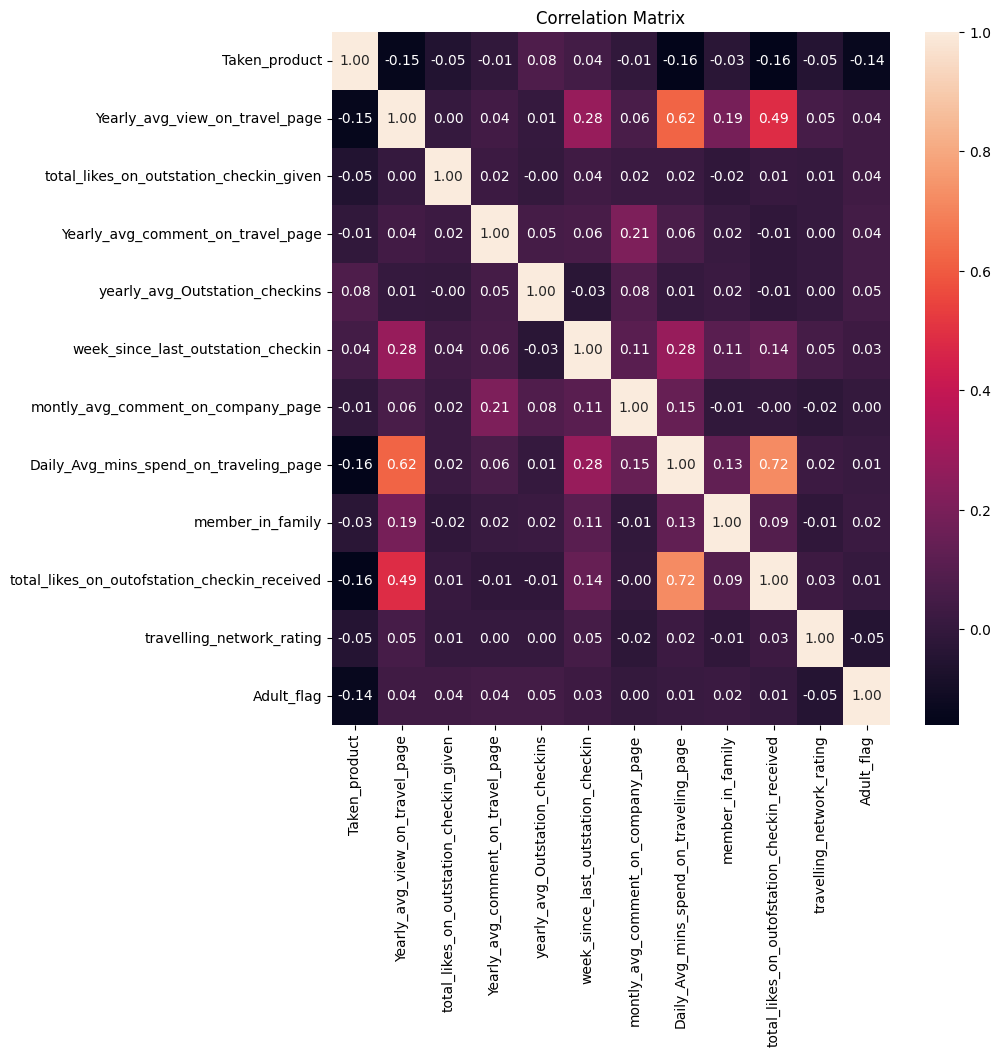

In [ ]:
#Plotting a correlation matrix to analyze our target column
df_subset=df[cols_to_plot_corr]
corr_matrix = df_subset.corr()
plt.figure(figsize=(9,9))
sns.heatmap(corr_matrix, annot=True,fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

**INSIGHT**


*   There is no significant correlation seen with respect to 'Taken_product' column.

**INFERENCE**


*   Poor correlation is very common in real world data.
*   Sometimes individual feature may not have a considerable correlation, but combinations of features predict target very well.


*   In our case, since the columns logically tell us that they may impact our target variable, we will still keep all the columns and go ahead with our ML model building.





In [ ]:
#Coverting to Yes & No value to be able to plot charts and graphs
df['Taken_product'] = df['Taken_product'].replace({
    1: 'Yes', 0:'No'})


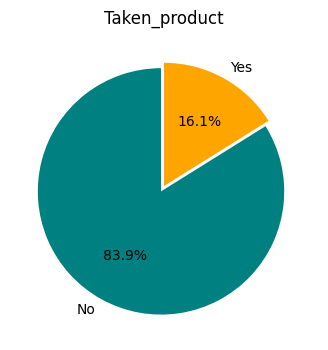

In [ ]:
#Plotting a Pie Chart to analyse 'Taken_product' column
value_count1= df['Taken_product'].value_counts()
plt.figure(figsize=(6,4))
colors_pie = ['#008080', '#FFA500']
plt.pie(value_count1, labels=value_count1.index, autopct='%1.1f%%', startangle=90, colors=colors_pie, explode=(0.05, 0))
plt.title('Taken_product')
plt.show()

**INSIGHT**
*   Most users have **not** purchased a ticket from the Airline.

  
**INFERENCE**

There could be three reasons

*   Users are not travelling much.
*   Users are travelling, but not purchasing tickets from the Airline
*   There is very low awareness of this airline among users.






In [ ]:
#checking how many users did not travel at all
print((df['yearly_avg_Outstation_checkins'] == 0).sum())


0


**INSIGHT**
*   Every user has travelled atleast once a year.

**INFERENCE**
*   Users are travelling, but not purchasing tickets from the Airline.





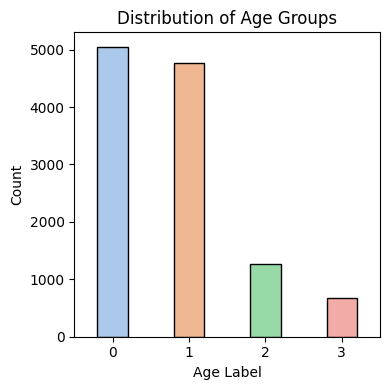

In [ ]:
plt.figure(figsize=(4,4))
sns.countplot(x='Adult_flag', data=df, palette='pastel', edgecolor='black',width =0.4)
plt.title('Distribution of Age Groups')
plt.xlabel('Age Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


**INSIGHT**


*   Around **80%** of users fall within the 15–35 age group, indicating a predominantly young audience.
*   Only 20% of users are aged 36 and above.

**NOTE**


*   We had assumed certain age groups for the encoded labels in the very beginning of our analysis







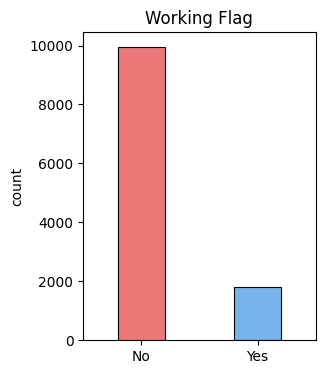

In [ ]:
#Analyzing the Working flag column
plt.figure(figsize=(3,4))
colors_working=['#ff6666','#66b3ff']
sns.countplot(x='working_flag', data = df, width=0.4, palette = colors_working, edgecolor='black', linewidth=0.8)
plt.xlabel('')
plt.title('Working Flag')
plt.show()

**INSIGHT**


*   About **85%** of users are not working.

**INFERENCE**


*   Since most users are not working, they might look out for cheaper tickets.
*   Since most users have not purchased a ticket, either the airline is a premium category carrier or the tickets are costlier than it's competitors.
*   It may also imply that users do not like the service of the airline.







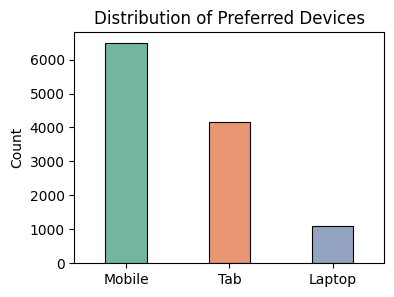

In [ ]:
#Analyzing the preffered device column
plt.figure(figsize=(4,3))
sns.countplot(x='preferred_device', data=df,width = 0.4, palette='Set2', edgecolor='black', linewidth=0.8)
plt.title('Distribution of Preferred Devices')
plt.xlabel('')
plt.ylabel('Count')
plt.show()

 **INSIGHT**


*   Mobile is the most preferred device.
*   Tab is the second most preferred device.
*   Laptop is the least preferred device, about **80%** lesser than Mobile.





In [ ]:
df['preferred_location_type'].dtypes

dtype('O')

In [ ]:
#changing dtype to categorical to make it easier to plot graphs
df['preferred_location_type'] = df['preferred_location_type'].astype('category')

In [ ]:
df['preferred_location_type'].dtypes

CategoricalDtype(categories=['Beach', 'Big Cities', 'Entertainment', 'Financial',
                  'Hill Stations', 'Historical site', 'Medical', 'Other',
                  'Trekking', 'Unknown'],
, ordered=False, categories_dtype=object)

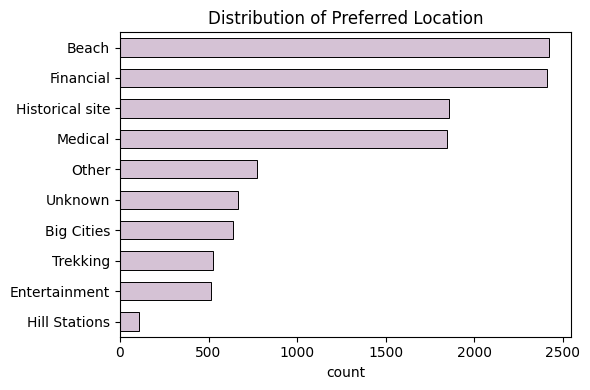

In [ ]:
#Analyzing preferred location column
order = df['preferred_location_type'].value_counts().index
plt.figure(figsize=(6,4))
sns.countplot(y='preferred_location_type', data=df,order =order,width = 0.6, edgecolor='black', linewidth=0.7,color='thistle')
plt.title('Distribution of Preferred Location')
plt.ylabel('')
plt.tight_layout()
plt.show()

**INSIGHT**


*   Beach and Financial are the most preferred locations.
*   Hill Sations are the least preferred locations.

**INFERENCE**


*   The Airline can focus more on marketing flights towards beach destinations.
*   Assuming Financial means business trips, Airline can also focus on more business oriented routes.





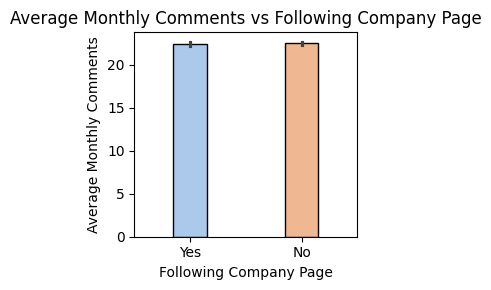

In [ ]:
plt.figure(figsize=(3,3))
sns.barplot( x='following_company_page', y='montly_avg_comment_on_company_page', data= df, estimator='mean',
    width=0.3, palette='pastel', edgecolor='black')

plt.title('Average Monthly Comments vs Following Company Page')
plt.xlabel('Following Company Page')
plt.ylabel('Average Monthly Comments')
plt.tight_layout()
plt.show()


**INSIGHT**


*   Users who are not following the company page are still interacting with the content on the page.


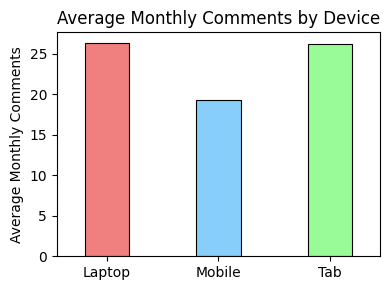

In [ ]:
device_comments = df.groupby('preferred_device')['montly_avg_comment_on_company_page'].mean()

# Plot
plt.figure(figsize=(4,3))
colors = ['lightcoral', 'lightskyblue', 'palegreen']
device_comments.plot(kind='bar', width = 0.4, edgecolor='black', linewidth=0.8,color=colors)
plt.title('Average Monthly Comments by Device')
plt.xlabel('')
plt.ylabel('Average Monthly Comments')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**INSIGHT**


*   Laptop and tablet users comment more on the company page.


*   Mobile users post around **10% lesser** comments than laptop and tablet users.

**INFERENCE**


*   To increase engagement, focus on improving the mobile experience.






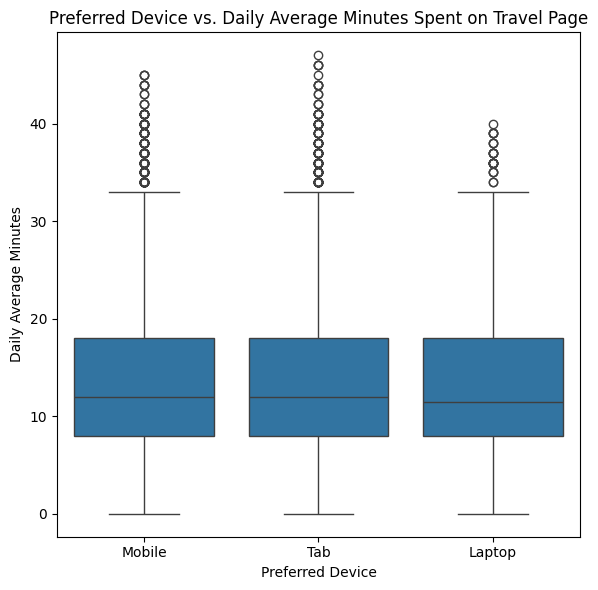

In [ ]:
#checking how device impacts engagaemnt
plt.figure(figsize=(6, 6))
sns.boxplot(x='preferred_device', y='Daily_Avg_mins_spend_on_traveling_page', data=df)

plt.title('Preferred Device vs. Daily Average Minutes Spent on Travel Page')
plt.xlabel('Preferred Device')
plt.ylabel('Daily Average Minutes')
plt.tight_layout()
plt.show()


**INSIGHT**


*   The type of device does not significantly impact the amount of time a user spends on a travel page daily.
*   Notably, no user spends more than 40 minutes on a laptop, while only a handful spend that much time on a mobile or a tab.



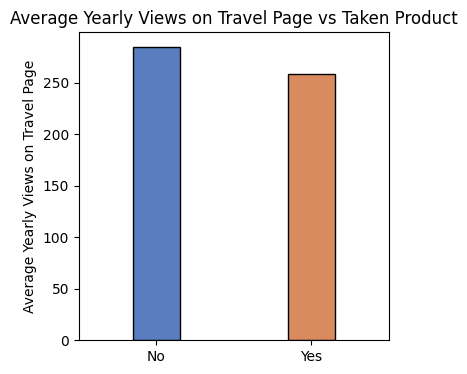

In [ ]:
# Bar plot
avg_views = df.groupby('Taken_product')['Yearly_avg_view_on_travel_page'].mean().reset_index()
plt.figure(figsize=(4, 4))
sns.barplot(x='Taken_product', y='Yearly_avg_view_on_travel_page', data=avg_views, palette='muted',width=0.3, edgecolor='black')
plt.title('Average Yearly Views on Travel Page vs Taken Product')
plt.xlabel('')
plt.ylabel('Average Yearly Views on Travel Page')
plt.show()


**INSIGHT**


*   Users who did not take the product have a higher average yearly view on the travel page compared to users who took the product.

**INFERENCE**
*   Users spending more time on the travel page are less likely to purchase the product.





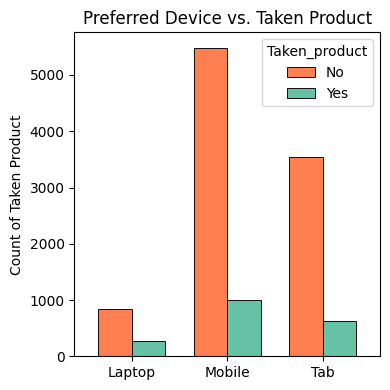

In [ ]:

device_contigency = pd.crosstab(df['preferred_device'], df['Taken_product'])

device_contigency.plot(kind='bar', figsize=(4,4),color=['#ff7f50','#66c2a5' ],width = 0.7,edgecolor='black',linewidth=0.65)
plt.title('Preferred Device vs. Taken Product')
plt.xlabel('')
plt.ylabel('Count of Taken Product')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**INSIGHT AND INFERENCE**


*   Mobile users exhibit a higher likelihood of purchasing the product, followed by Tab users.


*   Laptop users, on the other hand, show a lower posibility for purchasing tickets.












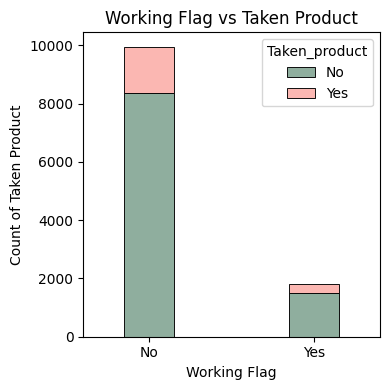

In [ ]:
# Calculate the counts of Taken_product per working_flag
working_taken_counts = pd.crosstab(df['working_flag'], df['Taken_product'])

# Plot a stacked bar chart
working_taken_counts.plot(kind='bar', stacked=True, figsize=(4,4), color=['#8fae9e', '#fbb7b2'],width = 0.3,edgecolor='black',linewidth=0.65)
plt.title('Working Flag vs Taken Product')
plt.xlabel('Working Flag')
plt.ylabel('Count of Taken Product')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**INSIGHT**


*   A majority of users(about 80%) who have purchased a ticket are not working.

**INFERENCE**


*   The high number of non-working ticket purchasers suggests that the airline may not be a premium carrier.
*   This trend could indicate that users are dissatisfied with the airline's service.
*   It may also point to airline not operating in business travel related sectors.







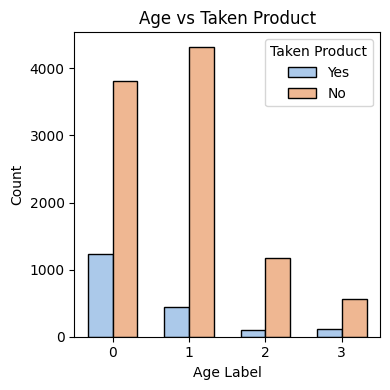

In [ ]:
plt.figure(figsize=(4,4))
sns.countplot(x='Adult_flag', hue='Taken_product', data=df, palette='pastel', edgecolor='black',width=0.65)
plt.title('Age vs Taken Product')
plt.xlabel('Age Label')
plt.ylabel('Count')
plt.legend(title='Taken Product')
plt.tight_layout()
plt.show()


**INSIGHT**


*   Users aged 15–35 are the primary purchasers of tickets accounting to 60% of ticket purchasers.


*   users aged over 35 are less likely to purchase a ticket.



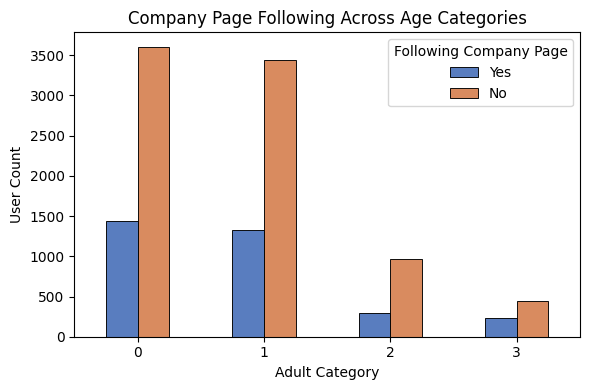

In [ ]:
#checking users engagement with company page and age distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Adult_flag', hue='following_company_page', data=df, palette = 'muted',width = 0.5,edgecolor='black',linewidth=0.65)
plt.title('Company Page Following Across Age Categories')
plt.xlabel('Adult Category')
plt.ylabel('User Count')
plt.legend(title='Following Company Page')
plt.tight_layout()
plt.show()


**INSIGHT**


*   Overall about 70 % users are not following the company page
*   Users aged 15–25 and 26–35 are the most likely to follow the company page.
*   Older age groups show significantly lower engagement in following the company page.


**INFERENCE**


*   If the Airline is promoting it's products on the company page, It is not reaching their target audience as most users are not following company page.


*   Airline needs to build content engagement strategies to improve following





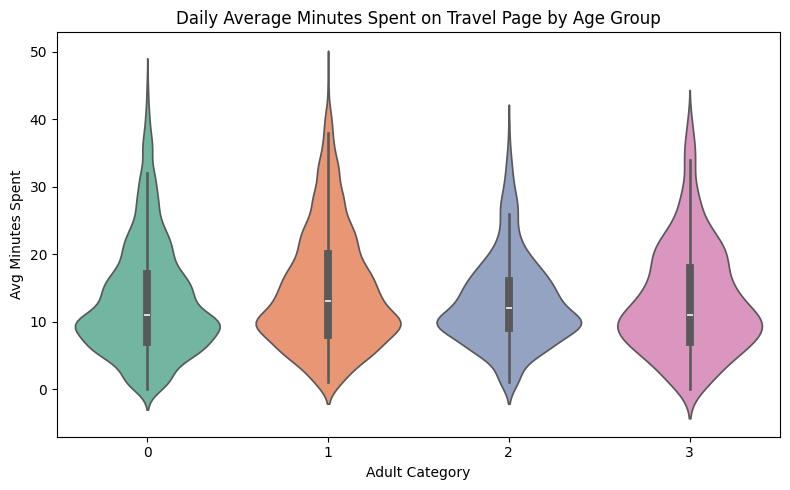

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Adult_flag', y='Daily_Avg_mins_spend_on_traveling_page', data=df, palette='Set2')
plt.title('Daily Average Minutes Spent on Travel Page by Age Group')
plt.xlabel('Adult Category')
plt.ylabel('Avg Minutes Spent')
plt.tight_layout()
plt.show()


**INSIGHT**



*   Most users, across all age groups, spend 5–15 minutes daily on the travel page.
*   Users aged 36 and above rarely spend more than 45 minutes per day.
*   Only a small portion of users aged 15–35 exceed 45 minutes of daily engagement.





